In [29]:
import os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna

# 경고 무시
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

### 비교 결과 산출 관련 함수

In [16]:
def load_data():
    """
    노트북 환경에서 hotel_bookings.csv 파일을 로드합니다.
    """
    # 노트북 환경에서는 __file__이 정의되지 않으므로 직접 경로 지정
    try:
        # 현재 디렉토리에서 상대 경로로 시도
        df = pd.read_csv('../data/hotel_bookings.csv')
        print("데이터 로드 성공 (상대 경로)")
        return df
    except FileNotFoundError:
        try:
            # 절대 경로로 시도
            df = pd.read_csv('/Users/wjsdndud/SKNAIcamp/02_Project/SKN21-2nd-5Team/data/hotel_bookings.csv')
            print("데이터 로드 성공 (절대 경로)")
            return df
        except FileNotFoundError:
            print("Error: hotel_bookings.csv 파일을 찾을 수 없습니다.")
            print("파일 경로를 확인해주세요.")
            return None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

In [17]:
def preprocess_data(df):
    """
    v1.py와 동일한 전처리 함수
    """
    df_proc = df.copy()
    
    # 1. country 결측치 처리
    mfc = df_proc['country'].mode()[0]
    df_proc['country'] = df_proc['country'].fillna(mfc)
    
    # 2. children 결측치 처리
    df_proc['children'] = df_proc['children'].fillna(0).astype(int)
    
    # 3. ADR 이상치 제거 (5000 초과, 음수)
    df_proc = df_proc[df_proc['adr'] <= 5000].copy()
    df_proc['adr'] = df_proc['adr'].apply(lambda x: x if x >= 0 else 0)
    
    print(f"\n데이터 클리닝 완료. Shape: {df_proc.shape}")
    
    useless_col = ['reservation_status', 'reservation_status_date', 'company']
    df_proc.drop(useless_col, axis=1, inplace=True)
    
    num_cols = df_proc.select_dtypes(include=[np.number]).columns
    cat_cols = df_proc.select_dtypes(include=['object']).columns
    
    # 숫자형 결측치 처리: 0으로 대체
    df_proc[num_cols] = df_proc[num_cols].fillna(0)
    
    # 범주형 결측치 처리: 'Unknown'으로 대체
    df_proc[cat_cols] = df_proc[cat_cols].fillna('Unknown')
    
    # 범주형 변수 인코딩 (One-Hot Encoding)
    cat_cols_for_ohe = df_proc.select_dtypes(include=['object', 'category']).columns
    df_proc = pd.get_dummies(df_proc, columns=cat_cols_for_ohe, drop_first=True)
    
    return df_proc


In [18]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test, scale_pos_weight):
    """
    5개 모델을 학습하고 평가합니다.
    """
    results = {}
    
    # 공통 하이퍼파라미터 설정 (v1.py 베이스라인 기준)
    # v1.py의 Optuna 결과를 기반으로 고정 파라미터 사용
    common_params = {
        'random_state': 42,
        'max_depth': 6,
        'n_estimators': 500,  # 공통으로 사용할 estimators 수
    }
    
    # 1. CatBoost
    print("Training CatBoost...")
    catboost_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=common_params['random_state'],
        verbose=False,
        depth=common_params['max_depth'],
        iterations=common_params['n_estimators'],
        learning_rate=0.1,
        class_weights=[1, scale_pos_weight]
    )
    catboost_model.fit(X_train, y_train)
    results['CatBoost'] = evaluate_model(catboost_model, X_test, y_test)
    
    # 2. XGBoost
    print("Training XGBoost...")
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=common_params['random_state'],
        max_depth=common_params['max_depth'],
        n_estimators=common_params['n_estimators'],
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    results['XGBoost'] = evaluate_model(xgb_model, X_test, y_test)
    
    # 3. Random Forest
    print("Training Random Forest...")
    rf_model = RandomForestClassifier(
        random_state=common_params['random_state'],
        max_depth=common_params['max_depth'],
        n_estimators=common_params['n_estimators'],
        class_weight={0: 1, 1: scale_pos_weight}
    )
    rf_model.fit(X_train, y_train)
    results['RandomForest'] = evaluate_model(rf_model, X_test, y_test)
    
    # 4. LightGBM (베이스라인)
    print("Training LightGBM...")
    lgbm_model = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        verbosity=-1,
        boosting_type='gbdt',
        random_state=common_params['random_state'],
        max_depth=common_params['max_depth'],
        n_estimators=common_params['n_estimators'],
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight
    )
    lgbm_model.fit(X_train, y_train)
    results['LightGBM'] = evaluate_model(lgbm_model, X_test, y_test)
    
    # 5. Logistic Regression
    print("Training Logistic Regression...")
    lr_model = LogisticRegression(
        random_state=common_params['random_state'],
        max_iter=1000,
        class_weight={0: 1, 1: scale_pos_weight}
    )
    lr_model.fit(X_train, y_train)
    results['LogisticRegression'] = evaluate_model(lr_model, X_test, y_test)
    
    return results


In [19]:
def evaluate_model(model, X_test, y_test):
    """
    모델을 평가하고 성능 지표를 반환합니다.
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    return {
        'accuracy': accuracy,
        'recall': recall,
        'auc': auc,
        'fpr': fpr,
        'tpr': tpr,
        'y_pred_proba': y_pred_proba
    }


In [20]:
def create_comparison_dataframe(results):
    """
    성능 비교 데이터프레임을 생성합니다.
    """
    comparison_data = []
    for model_name, metrics in results.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Recall': metrics['recall'],
            'AUC': metrics['auc']
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('AUC', ascending=False).reset_index(drop=True)
    
    return df_comparison


In [21]:
def plot_performance_comparison(df_comparison, results):
    """
    성능 비교 시각화
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. 성능 지표 비교 막대 그래프
    metrics = ['Accuracy', 'Recall', 'AUC']
    x = np.arange(len(df_comparison))
    width = 0.25
    
    for i, metric in enumerate(metrics):
        axes[0, 0].bar(x + i*width, df_comparison[metric], width, label=metric)
    
    axes[0, 0].set_xlabel('Models')
    axes[0, 0].set_ylabel('Performance Score')
    axes[0, 0].set_title('모델별 성능 지표 비교')
    axes[0, 0].set_xticks(x + width)
    axes[0, 0].set_xticklabels(df_comparison['Model'], rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. ROC 곡선
    for model_name, metrics in results.items():
        axes[0, 1].plot(metrics['fpr'], metrics['tpr'], 
                       label=f"{model_name} (AUC = {metrics['auc']:.3f})")
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('ROC 곡선 비교')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. AUC 점수 막대 그래프
    colors = plt.cm.viridis(np.linspace(0, 1, len(df_comparison)))
    bars = axes[1, 0].bar(df_comparison['Model'], df_comparison['AUC'], color=colors)
    axes[1, 0].set_ylabel('AUC Score')
    axes[1, 0].set_title('모델별 AUC 점수')
    axes[1, 0].set_ylim(0.5, 1.0)
    for bar, auc in zip(bars, df_comparison['AUC']):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{auc:.3f}', ha='center', va='bottom')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. 정확도와 재현율 산점도
    axes[1, 1].scatter(df_comparison['Accuracy'], df_comparison['Recall'], 
                      c=df_comparison['AUC'], cmap='viridis', s=100, alpha=0.7)
    
    for i, model in enumerate(df_comparison['Model']):
        axes[1, 1].annotate(model, 
                           (df_comparison.iloc[i]['Accuracy'], df_comparison.iloc[i]['Recall']),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    axes[1, 1].set_xlabel('Accuracy')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('정확도 vs 재현율 (색상: AUC)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 컬러바 추가
    cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
    cbar.set_label('AUC Score')
    
    plt.tight_layout()
    plt.show()


In [22]:
def find_best_model(df_comparison):
    """
    최고 성능 모델을 찾습니다.
    """
    # AUC 기준으로 최고 모델 선정
    best_model = df_comparison.iloc[0]
    
    print("=" * 60)
    print("🏆 최고 성능 모델")
    print("=" * 60)
    print(f"모델명: {best_model['Model']}")
    print(f"AUC: {best_model['AUC']:.4f}")
    print(f"Accuracy: {best_model['Accuracy']:.4f}")
    print(f"Recall: {best_model['Recall']:.4f}")
    print("=" * 60)
    
    return best_model


🚀 5개 모델 성능 비교 시작
데이터 로드 성공 (상대 경로)

📊 데이터 전처리 시작...

데이터 클리닝 완료. Shape: (119389, 32)
전처리 완료. 최종 Shape: (119389, 247)

⚖️ 클래스 불균형 정보:
Negative samples: 75166
Positive samples: 44223
Scale pos weight: 1.70

🤖 모델 학습 및 평가 시작...
Training CatBoost...
전처리 완료. 최종 Shape: (119389, 247)

⚖️ 클래스 불균형 정보:
Negative samples: 75166
Positive samples: 44223
Scale pos weight: 1.70

🤖 모델 학습 및 평가 시작...
Training CatBoost...
Training XGBoost...
Training XGBoost...
Training Random Forest...
Training Random Forest...
Training LightGBM...
Training LightGBM...
Training Logistic Regression...
Training Logistic Regression...

📋 모델별 성능 비교 결과:

📋 모델별 성능 비교 결과:


,Model,Accuracy,Recall,AUC
0,LightGBM,0.8778,0.8769,0.9545
1,XGBoost,0.8787,0.8765,0.9545
2,CatBoost,0.8756,0.8759,0.9526
3,RandomForest,0.8328,0.7129,0.9031
4,LogisticRegression,0.7925,0.7574,0.8741



📈 성능 비교 시각화 생성 중...


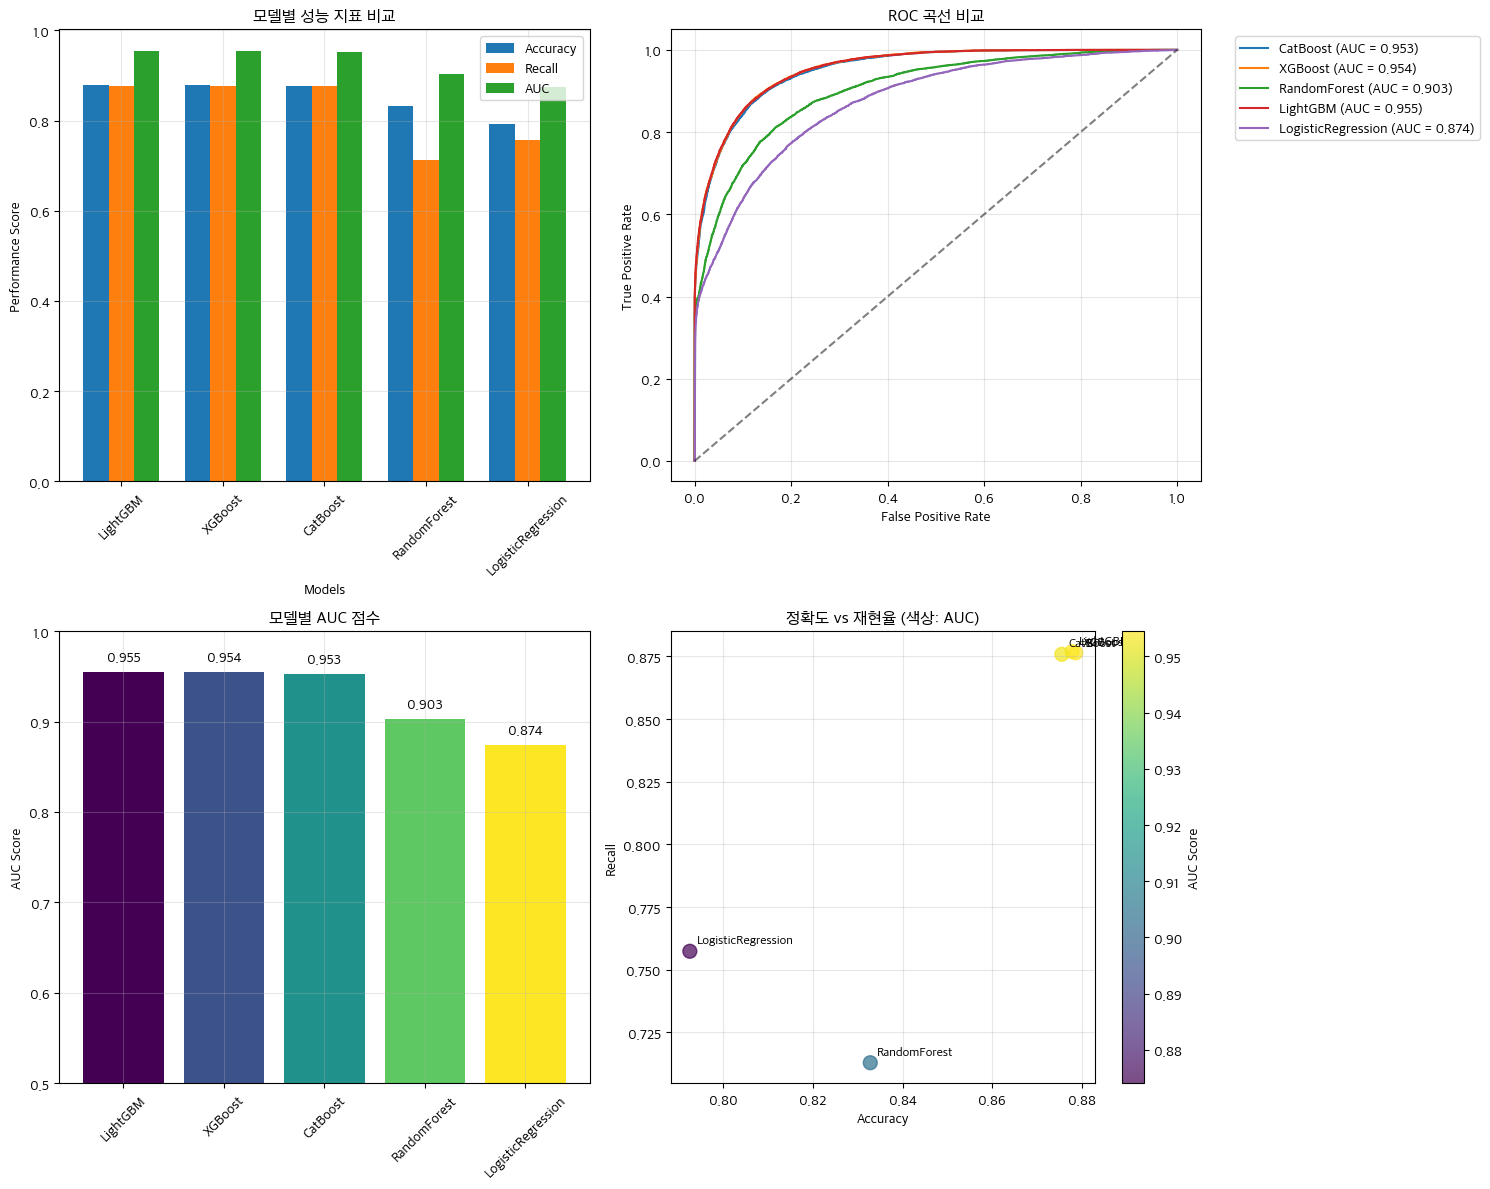

🏆 최고 성능 모델
모델명: LightGBM
AUC: 0.9545
Accuracy: 0.8778
Recall: 0.8769

💾 결과가 저장되었습니다: ../results/model_comparison_results.csv

✅ 모든 작업이 완료되었습니다!


In [26]:
# 5개 모델 성능 비교 실행

print("=" * 60)
print("🚀 5개 모델 성능 비교 시작")
print("=" * 60)

# 1. 데이터 로드
raw_data = load_data()
if raw_data is not None:
    
    # 2. 전처리
    print("\n📊 데이터 전처리 시작...")
    processed_data = preprocess_data(raw_data)
    print(f"전처리 완료. 최종 Shape: {processed_data.shape}")
    
    # 3. 데이터 분할
    target = 'is_canceled'
    X = processed_data.drop(target, axis=1)
    y = processed_data[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 클래스 불균형 처리를 위한 가중치 계산
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    scale_pos_weight = neg / pos
    print(f"\n⚖️ 클래스 불균형 정보:")
    print(f"Negative samples: {neg}")
    print(f"Positive samples: {pos}")
    print(f"Scale pos weight: {scale_pos_weight:.2f}")
    
    # 4. 모델 학습 및 평가
    print(f"\n🤖 모델 학습 및 평가 시작...")
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test, scale_pos_weight)
    
    # 5. 성능 비교 데이터프레임 생성
    df_comparison = create_comparison_dataframe(results)
    
    print("\n📋 모델별 성능 비교 결과:")
    display(df_comparison.round(4))
    
    # 6. 시각화
    print("\n📈 성능 비교 시각화 생성 중...")
    plot_performance_comparison(df_comparison, results)
    
    # 7. 최고 모델 선정
    best_model = find_best_model(df_comparison)
    
    # 8. 결과 저장
    try:
        output_dir = '../results'
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'model_comparison_results.csv')
        df_comparison.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"\n💾 결과가 저장되었습니다: {output_path}")
    except Exception as e:
        print(f"\n⚠️ 결과 저장 중 오류 발생: {e}")
        print("결과는 메모리에 저장되었습니다.")
    
    print("\n✅ 모든 작업이 완료되었습니다!")

else:
    print("❌ 데이터 로드에 실패했습니다. 파일 경로를 확인해주세요.")

### 상위 3개 모델 하이퍼파라미터 튜닝 및 비교
최고 성능을 보인 **LightGBM**, **XGBoost**, **CatBoost** 모델들의 하이퍼파라미터를 Optuna로 최적화하고 성능을 다시 비교해보겠습니다.

In [32]:
N_TRIALS = 50
tuned_results = {}

##### LightGBM 최적화 및 재학습

In [31]:
def optimize_lightgbm(X_train, y_train, scale_pos_weight, n_trials=50):
    """LightGBM 하이퍼파라미터 최적화"""
    
    def objective(trial):
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'random_state': 42,
            'scale_pos_weight': scale_pos_weight,
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        }
        
        model = lgb.LGBMClassifier(**params)
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
        return cv_scores.mean()
    
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params


In [34]:
best_lgb_params = optimize_lightgbm(X_train, y_train, scale_pos_weight, n_trials=N_TRIALS)
print(f"✅ LightGBM 최적 파라미터: {best_lgb_params}")

# 최적 파라미터로 모델 재학습 및 평가
lgb_tuned = lgb.LGBMClassifier(**best_lgb_params, objective='binary', metric='auc', 
                               verbosity=-1, random_state=42, scale_pos_weight=scale_pos_weight)
lgb_tuned.fit(X_train, y_train)
tuned_results['LightGBM_Tuned'] = evaluate_model(lgb_tuned, X_test, y_test)

# CV AUC vs Test AUC 비교
cv_auc_lgb = cross_val_score(lgb_tuned, X_train, y_train, cv=3, scoring='roc_auc').mean()
print(f"   CV AUC: {cv_auc_lgb:.4f}, Test AUC: {tuned_results['LightGBM_Tuned']['auc']:.4f}")


Best trial: 40. Best value: 0.958084: 100%|██████████| 50/50 [12:48<00:00, 15.37s/it]



✅ LightGBM 최적 파라미터: {'num_leaves': 70, 'max_depth': 10, 'learning_rate': 0.11635143613191525, 'n_estimators': 999, 'min_child_samples': 9, 'subsample': 0.5887663591658137, 'colsample_bytree': 0.6898069657911894, 'reg_alpha': 0.12280749797571977, 'reg_lambda': 0.31096031623727743}
   CV AUC: 0.9581, Test AUC: 0.9607
   CV AUC: 0.9581, Test AUC: 0.9607


In [ ]:
def optimize_xgboost(X_train, y_train, scale_pos_weight, n_trials=50):
    """XGBoost 하이퍼파라미터 최적화"""
    
    def objective(trial):
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'random_state': 42,
            'verbosity': 0,
            'scale_pos_weight': scale_pos_weight,
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 1.0),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        }
        
        model = xgb.XGBClassifier(**params)
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
        return cv_scores.mean()
    
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params


In [ ]:
best_xgb_params = optimize_xgboost(X_train, y_train, scale_pos_weight, n_trials=N_TRIALS)
print(f"✅ XGBoost 최적 파라미터: {best_xgb_params}")

# 최적 파라미터로 모델 재학습 및 평가
xgb_tuned = xgb.XGBClassifier(**best_xgb_params, objective='binary:logistic', 
                              eval_metric='auc', random_state=42, verbosity=0, 
                              scale_pos_weight=scale_pos_weight)
xgb_tuned.fit(X_train, y_train)
tuned_results['XGBoost_Tuned'] = evaluate_model(xgb_tuned, X_test, y_test)

# CV AUC vs Test AUC 비교
cv_auc_xgb = cross_val_score(xgb_tuned, X_train, y_train, cv=3, scoring='roc_auc').mean()
print(f"   CV AUC: {cv_auc_xgb:.4f}, Test AUC: {tuned_results['XGBoost_Tuned']['auc']:.4f}")

In [ ]:
def optimize_catboost(X_train, y_train, scale_pos_weight, n_trials=50):
    """CatBoost 하이퍼파라미터 최적화"""
    
    def objective(trial):
        params = {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'random_seed': 42,
            'verbose': False,
            'class_weights': [1, scale_pos_weight],
            'depth': trial.suggest_int('depth', 3, 10),
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        }
        
        # bootstrap_type이 'Bayesian'이 아닌 경우 bagging_temperature 제거
        if params['bootstrap_type'] != 'Bayesian':
            del params['bagging_temperature']
        
        model = CatBoostClassifier(**params)
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
        return cv_scores.mean()
    
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params


In [ ]:
best_catboost_params = optimize_catboost(X_train, y_train, scale_pos_weight, n_trials=N_TRIALS)
print(f"✅ CatBoost 최적 파라미터: {best_catboost_params}")

# 최적 파라미터로 모델 재학습 및 평가
catboost_tuned = CatBoostClassifier(**best_catboost_params, loss_function='Logloss', 
                                    eval_metric='AUC', random_seed=42, verbose=False,
                                    class_weights=[1, scale_pos_weight])
catboost_tuned.fit(X_train, y_train)
tuned_results['CatBoost_Tuned'] = evaluate_model(catboost_tuned, X_test, y_test)

In [ ]:
# 2. XGBoost 최적화
print(f"\n📊 2/3: XGBoost 최적화 중...")


# 3. CatBoost 최적화
print(f"\n📊 3/3: CatBoost 최적화 중...")


# CV AUC vs Test AUC 비교
cv_auc_catboost = cross_val_score(catboost_tuned, X_train, y_train, cv=3, scoring='roc_auc').mean()
print(f"   CV AUC: {cv_auc_catboost:.4f}, Test AUC: {tuned_results['CatBoost_Tuned']['auc']:.4f}")

print("\n🎉 모든 모델의 하이퍼파라미터 최적화가 완료되었습니다!")
print("\n📋 최적화된 모델별 최종 성능:")

for model_name, result in tuned_results.items():
    model_display = model_name.replace('_Tuned', '')
    print(f"  {model_display}: AUC={result['auc']:.4f}, Accuracy={result['accuracy']:.4f}, Recall={result['recall']:.4f}")

# 최적 파라미터 정보 저장
optimization_results = {
    'LightGBM': best_lgb_params,
    'XGBoost': best_xgb_params,
    'CatBoost': best_catboost_params
}

print(f"\n💾 최적화 결과가 메모리에 저장되었습니다.")
print("   - tuned_results: 튜닝된 모델들의 평가 결과")
print("   - optimization_results: 각 모델의 최적 하이퍼파라미터")

In [ ]:
# 튜닝 전후 성능 비교

# 튜닝된 모델 성능 비교 데이터프레임 생성
df_tuned_comparison = create_comparison_dataframe(tuned_results)

print("📋 하이퍼파라미터 튜닝 후 성능 비교 결과:")
display(df_tuned_comparison.round(4))

# 튜닝 전후 비교를 위한 데이터프레임 생성
before_after_data = []

# 원본 모델 결과 (이전 결과에서 상위 3개)
original_top3 = df_comparison.head(3).copy()
original_top3['Stage'] = 'Before_Tuning'
original_top3['Model_Stage'] = original_top3['Model'] + '_Before'

# 튜닝된 모델 결과
tuned_df = df_tuned_comparison.copy()
tuned_df['Stage'] = 'After_Tuning'
tuned_df['Model'] = tuned_df['Model'].str.replace('_Tuned', '')
tuned_df['Model_Stage'] = tuned_df['Model'] + '_After'

# 합치기
comparison_df = pd.concat([original_top3, tuned_df], ignore_index=True)

print("\n📊 튜닝 전후 상세 비교:")
display(comparison_df[['Model', 'Stage', 'Accuracy', 'Recall', 'AUC']].round(4))

# 성능 개선 정도 계산
improvement_data = []
for model in ['LightGBM', 'XGBoost', 'CatBoost']:
    before = original_top3[original_top3['Model'] == model].iloc[0] if len(original_top3[original_top3['Model'] == model]) > 0 else None
    after = tuned_df[tuned_df['Model'] == model].iloc[0] if len(tuned_df[tuned_df['Model'] == model]) > 0 else None
    
    if before is not None and after is not None:
        improvement_data.append({
            'Model': model,
            'AUC_Before': before['AUC'],
            'AUC_After': after['AUC'],
            'AUC_Improvement': after['AUC'] - before['AUC'],
            'Accuracy_Before': before['Accuracy'],
            'Accuracy_After': after['Accuracy'],
            'Accuracy_Improvement': after['Accuracy'] - before['Accuracy'],
            'Recall_Before': before['Recall'],
            'Recall_After': after['Recall'],
            'Recall_Improvement': after['Recall'] - before['Recall']
        })

improvement_df = pd.DataFrame(improvement_data)

print("\n📈 성능 개선도 분석:")
display(improvement_df.round(4))

# 최종 최고 성능 모델 선정
final_best_model = find_best_model(df_tuned_comparison)

print(f"\n🎯 하이퍼파라미터 튜닝을 통한 성능 향상:")
for _, row in improvement_df.iterrows():
    model_name = row['Model']
    auc_improvement = row['AUC_Improvement']
    status = "📈 향상" if auc_improvement > 0 else "📉 감소" if auc_improvement < 0 else "➡️ 동일"
    print(f"{model_name}: AUC {auc_improvement:+.4f} {status}")

# 최종 결과 저장
try:
    output_dir = '../results'
    os.makedirs(output_dir, exist_ok=True)
    
    # 튜닝 후 결과 저장
    tuned_output_path = os.path.join(output_dir, 'tuned_model_comparison_results.csv')
    df_tuned_comparison.to_csv(tuned_output_path, index=False, encoding='utf-8-sig')
    
    # 개선도 분석 저장
    improvement_output_path = os.path.join(output_dir, 'model_improvement_analysis.csv')
    improvement_df.to_csv(improvement_output_path, index=False, encoding='utf-8-sig')
    
    print(f"\n💾 튜닝 결과가 저장되었습니다:")
    print(f"   - 튜닝 후 성능: {tuned_output_path}")
    print(f"   - 개선도 분석: {improvement_output_path}")
except Exception as e:
    print(f"\n⚠️ 결과 저장 중 오류 발생: {e}")

print("\n✅ 하이퍼파라미터 튜닝 및 비교 분석이 완료되었습니다!")

In [ ]:
# 튜닝된 모델들의 시각화

def plot_tuned_models_comparison(df_tuned, tuned_results, improvement_df):
    """튜닝된 모델들의 성능 비교 시각화"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. 튜닝 후 성능 지표 비교
    metrics = ['Accuracy', 'Recall', 'AUC']
    x = np.arange(len(df_tuned))
    width = 0.25
    
    for i, metric in enumerate(metrics):
        axes[0, 0].bar(x + i*width, df_tuned[metric], width, label=metric)
    
    axes[0, 0].set_xlabel('Models')
    axes[0, 0].set_ylabel('Performance Score')
    axes[0, 0].set_title('튜닝 후 모델별 성능 지표')
    axes[0, 0].set_xticks(x + width)
    axes[0, 0].set_xticklabels(df_tuned['Model'].str.replace('_Tuned', ''), rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 튜닝 후 ROC 곡선
    for model_name, metrics_dict in tuned_results.items():
        model_display_name = model_name.replace('_Tuned', '')
        axes[0, 1].plot(metrics_dict['fpr'], metrics_dict['tpr'], 
                       label=f"{model_display_name} (AUC = {metrics_dict['auc']:.3f})")
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('튜닝 후 ROC 곡선 비교')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. AUC 개선도 비교
    colors = ['#ff7f0e', '#2ca02c', '#d62728']  # Orange, Green, Red
    bars = axes[0, 2].bar(improvement_df['Model'], improvement_df['AUC_Improvement'], 
                         color=colors, alpha=0.7)
    axes[0, 2].set_ylabel('AUC Improvement')
    axes[0, 2].set_title('하이퍼파라미터 튜닝 후 AUC 개선도')
    axes[0, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 개선도 수치 표시
    for bar, improvement in zip(bars, improvement_df['AUC_Improvement']):
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, height + 0.0005 if height >= 0 else height - 0.0005,
                       f'{improvement:+.4f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    axes[0, 2].tick_params(axis='x', rotation=45)
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. 정확도 개선도 비교
    bars = axes[1, 0].bar(improvement_df['Model'], improvement_df['Accuracy_Improvement'], 
                         color=colors, alpha=0.7)
    axes[1, 0].set_ylabel('Accuracy Improvement')
    axes[1, 0].set_title('정확도 개선도')
    axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    for bar, improvement in zip(bars, improvement_df['Accuracy_Improvement']):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, height + 0.001 if height >= 0 else height - 0.001,
                       f'{improvement:+.4f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. 재현율 개선도 비교
    bars = axes[1, 1].bar(improvement_df['Model'], improvement_df['Recall_Improvement'], 
                         color=colors, alpha=0.7)
    axes[1, 1].set_ylabel('Recall Improvement')
    axes[1, 1].set_title('재현율 개선도')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    for bar, improvement in zip(bars, improvement_df['Recall_Improvement']):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, height + 0.001 if height >= 0 else height - 0.001,
                       f'{improvement:+.4f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. 튜닝 전후 AUC 비교 (스택 바)
    models = improvement_df['Model']
    before_auc = improvement_df['AUC_Before']
    after_auc = improvement_df['AUC_After']
    
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = axes[1, 2].bar(x - width/2, before_auc, width, label='튜닝 전', alpha=0.8)
    bars2 = axes[1, 2].bar(x + width/2, after_auc, width, label='튜닝 후', alpha=0.8)
    
    axes[1, 2].set_ylabel('AUC Score')
    axes[1, 2].set_title('튜닝 전후 AUC 비교')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(models, rotation=45)
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim(0.93, 0.97)  # AUC 범위에 맞게 조정
    
    # 수치 표시
    for bar in bars1:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, height + 0.001,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, height + 0.001,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# 시각화 실행
print("\n📊 튜닝된 모델들의 성능 비교 시각화:")
plot_tuned_models_comparison(df_tuned_comparison, tuned_results, improvement_df)

In [ ]:
# 고성능 모델 세 가지 하이퍼파라미터 튜닝 및 비교 결과 산출
